# FinOps for AI Workloads: Visual Analysis

This notebook visualizes the synthetic dataset shipped in `/data` and runs
the same analysis the CLI scripts produce, just with charts instead of
ASCII bars.

For terminal output, run the four scripts in `/analysis`. The notebook is
the version with charts for visual review.

In [1]:
# Setup
import sys, os, json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Make the analysis package importable from anywhere
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root / "analysis"))

from parse_focus import (
    load_focus_data,
    summary_totals,
    summary_by_team,
    summary_by_pricing,
    summary_by_resource_type,
    summary_by_day,
)
from gpu_cost_analyzer import detect_idle, pricing_mix, detect_training_spikes
from inference_cost_calc import per_resource_cost_economics, per_instance_breakeven, filter_inference

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_PATH = repo_root / "data" / "ai-workload-synthetic.csv"
df = load_focus_data(DATA_PATH)
print(f"Loaded {len(df)} records covering {df['ChargePeriodStart'].min().date()} to {df['ChargePeriodEnd'].max().date()}")

Loaded 240 records covering 2026-04-01 to 2026-05-01


## Top-line metrics

The summary you would put on the first slide of a board deck.

In [2]:
totals = summary_totals(df)
print(f"Total effective cost:  ${totals['total_effective']:>12,.2f}")
print(f"Total list cost:       ${totals['total_list']:>12,.2f}")
print(f"Discount captured:     ${totals['discount']:>12,.2f}  ({totals['discount_pct']:.1f}%)")
print(f"Records:               {totals['record_count']:,}")
print(f"Resources:             {totals['resource_count']}")

Total effective cost:  $   11,786.72
Total list cost:       $   17,554.26
Discount captured:     $    5,767.53  (32.9%)
Records:               240
Resources:             8


## Daily cost trend, with training spike highlighted

What the executive team sees first. The April 15 spike is the engineered
"week three training event" in the synthetic data, and it correctly trips
the spike detector in `gpu_cost_analyzer.py`.

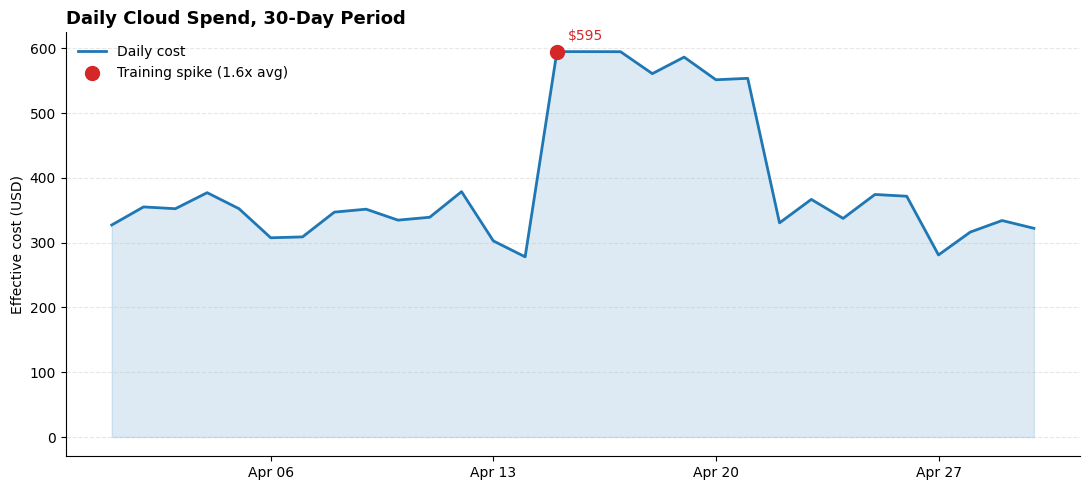

In [3]:
daily = summary_by_day(df).reset_index()
daily["Day"] = pd.to_datetime(daily["Day"])

spikes = detect_training_spikes(df)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(daily["Day"], daily["EffectiveCost"], linewidth=2, color="#1f77b4", label="Daily cost")
ax.fill_between(daily["Day"], daily["EffectiveCost"], alpha=0.15, color="#1f77b4")

if not spikes.empty:
    for _, row in spikes.iterrows():
        spike_day = pd.to_datetime(row["Day"])
        spike_cost = row["EffectiveCost"]
        ax.scatter([spike_day], [spike_cost], color="#d62728", s=100, zorder=5, label=f"Training spike ({row['Multiplier']:.1f}x avg)")
        ax.annotate(f"${spike_cost:,.0f}", xy=(spike_day, spike_cost), xytext=(8, 8), textcoords="offset points", fontsize=10, color="#d62728")

ax.set_title("Daily Cloud Spend, 30-Day Period", fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("Effective cost (USD)")
ax.set_xlabel("")
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

## Cost by team over time

Stacked area showing how spend distributes across `team-a`, `team-b`, and
the untagged research workload. The grey untagged band is the easy first
remediation target: assign a `cost-team` tag and that band moves into one
of the colored bands.

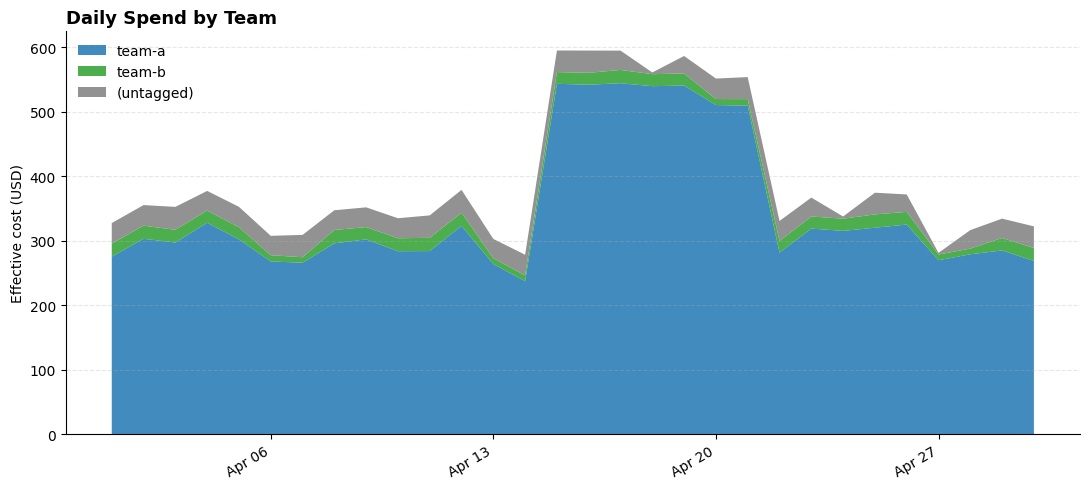

In [4]:
# Daily cost by team
df["TeamLabel"] = df["CostTeam"].fillna("(untagged)")
daily_team = df.groupby([df["ChargePeriodStart"].dt.date, "TeamLabel"])["EffectiveCost"].sum().unstack(fill_value=0)

# Order columns so untagged is on top of the stack for visibility
ordered = [c for c in ["team-a", "team-b", "(untagged)"] if c in daily_team.columns]
daily_team = daily_team[ordered]

colors = {"team-a": "#1f77b4", "team-b": "#2ca02c", "(untagged)": "#7f7f7f"}
team_colors = [colors[c] for c in daily_team.columns]

fig, ax = plt.subplots(figsize=(11, 5))
ax.stackplot(daily_team.index, daily_team.T, labels=daily_team.columns, colors=team_colors, alpha=0.85)
ax.set_title("Daily Spend by Team", fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("Effective cost (USD)")
ax.set_xlabel("")
ax.legend(loc="upper left", frameon=False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

# Format x-axis dates
fig.autofmt_xdate()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.tight_layout()
plt.show()

## Tag compliance: where the untagged spend lives

The 7.3% untagged bar is one resource. Tagging it once eliminates the
entire compliance gap.

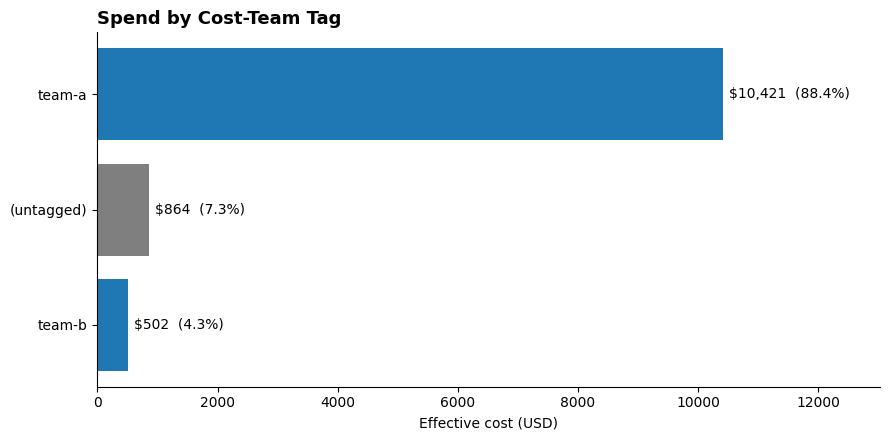

In [5]:
team_summary = summary_by_team(df).reset_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
bar_colors = ["#7f7f7f" if label == "(untagged)" else "#1f77b4" for label in team_summary["TeamLabel"]]
bars = ax.barh(team_summary["TeamLabel"], team_summary["EffectiveCost"], color=bar_colors)

for bar, value in zip(bars, team_summary["EffectiveCost"]):
    pct = value / team_summary["EffectiveCost"].sum() * 100
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2,
            f"${value:,.0f}  ({pct:.1f}%)",
            va="center", fontsize=10)

ax.set_title("Spend by Cost-Team Tag", fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel("Effective cost (USD)")
ax.set_xlim(0, team_summary["EffectiveCost"].max() * 1.25)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Pricing mix: what's hedged and what isn't

Reserved Instances are doing most of the discount work in this workload
portfolio. The Standard (on-demand) bar represents the migration
opportunity surfaced in `gpu_cost_analyzer.py`.

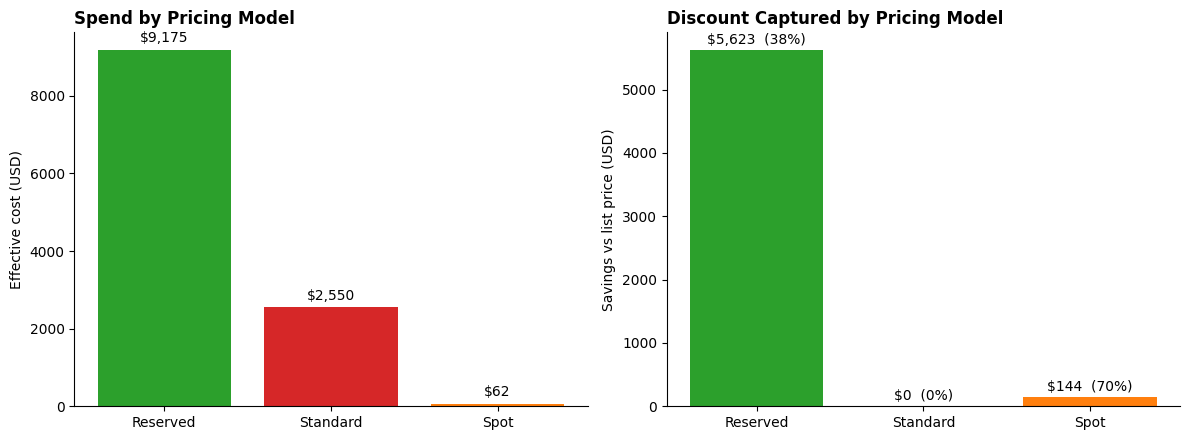

In [6]:
pricing_summary = summary_by_pricing(df).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: spend by pricing model
colors_pricing = {"Reserved": "#2ca02c", "Standard": "#d62728", "Spot": "#ff7f0e"}
bar_colors_p = [colors_pricing.get(c, "#888888") for c in pricing_summary["PricingCategory"]]
axes[0].bar(pricing_summary["PricingCategory"], pricing_summary["EffectiveCost"], color=bar_colors_p)
for i, (cat, cost) in enumerate(zip(pricing_summary["PricingCategory"], pricing_summary["EffectiveCost"])):
    axes[0].text(i, cost + 200, f"${cost:,.0f}", ha="center", fontsize=10)
axes[0].set_title("Spend by Pricing Model", fontsize=12, fontweight="bold", loc="left")
axes[0].set_ylabel("Effective cost (USD)")

# Right: discount captured per pricing model
pricing_summary["Saved"] = pricing_summary["ListCost"] - pricing_summary["EffectiveCost"]
axes[1].bar(pricing_summary["PricingCategory"], pricing_summary["Saved"], color=bar_colors_p)
for i, (cat, save, list_cost) in enumerate(zip(pricing_summary["PricingCategory"], pricing_summary["Saved"], pricing_summary["ListCost"])):
    pct = (save / list_cost * 100) if list_cost else 0
    axes[1].text(i, save + 100, f"${save:,.0f}  ({pct:.0f}%)", ha="center", fontsize=10)
axes[1].set_title("Discount Captured by Pricing Model", fontsize=12, fontweight="bold", loc="left")
axes[1].set_ylabel("Savings vs list price (USD)")

plt.tight_layout()
plt.show()

## Cost per 1,000 inferences: pricing tier comparison

Same workload, three pricing tiers. Spot is roughly one-third the cost of
on-demand for fault-tolerant inference.

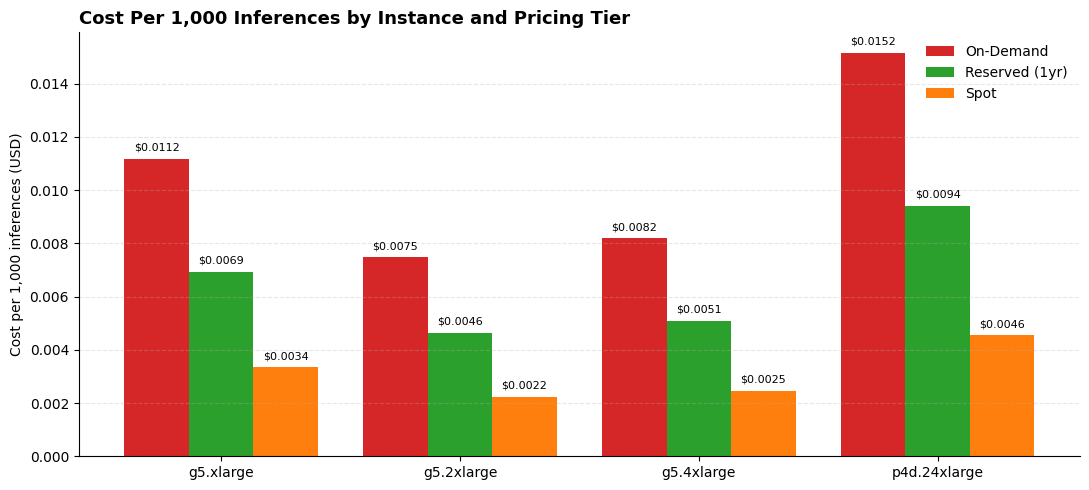

In [7]:
breakeven = per_instance_breakeven()

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(breakeven))
width = 0.27

ax.bar([i - width for i in x], breakeven["OnDemandCostPer1k"], width, label="On-Demand", color="#d62728")
ax.bar(x, breakeven["ReservedCostPer1k"], width, label="Reserved (1yr)", color="#2ca02c")
ax.bar([i + width for i in x], breakeven["SpotCostPer1k"], width, label="Spot", color="#ff7f0e")

ax.set_xticks(x)
ax.set_xticklabels(breakeven["InstanceType"])
ax.set_ylabel("Cost per 1,000 inferences (USD)")
ax.set_title("Cost Per 1,000 Inferences by Instance and Pricing Tier", fontsize=13, fontweight="bold", loc="left")
ax.legend(frameon=False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

# Add value labels on top of bars
for i, row in breakeven.reset_index(drop=True).iterrows():
    ax.text(i - width, row["OnDemandCostPer1k"] + 0.0003, f"${row['OnDemandCostPer1k']:.4f}", ha="center", fontsize=8)
    ax.text(i, row["ReservedCostPer1k"] + 0.0003, f"${row['ReservedCostPer1k']:.4f}", ha="center", fontsize=8)
    ax.text(i + width, row["SpotCostPer1k"] + 0.0003, f"${row['SpotCostPer1k']:.4f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

## Cost concentration: the Pareto view

Two resources drive 85% of GPU spend. The optimization conversation isn't
diffuse - it's two clear targets.

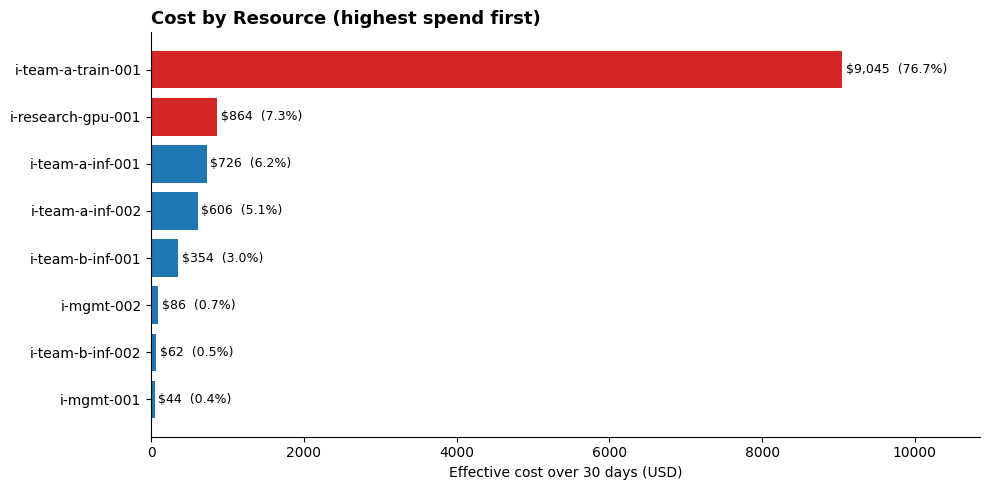

In [8]:
resource_summary = df.groupby("ResourceId")["EffectiveCost"].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors_res = ["#d62728" if "research" in r or "train" in r else "#1f77b4" for r in resource_summary.index]
bars = ax.barh(resource_summary.index, resource_summary.values, color=colors_res)

for bar, value in zip(bars, resource_summary.values):
    pct = value / resource_summary.sum() * 100
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
            f"${value:,.0f}  ({pct:.1f}%)",
            va="center", fontsize=9)

ax.set_title("Cost by Resource (highest spend first)", fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel("Effective cost over 30 days (USD)")
ax.set_xlim(0, resource_summary.max() * 1.2)
plt.tight_layout()
plt.show()

## Summary

Five charts, one screen each:

1. The 30-day spend curve, with the training spike automatically detected.
2. How spend distributes across teams, with the untagged band visible.
3. Tag compliance: 92.7% fully tagged, 7.3% in one resource.
4. Pricing model mix and discount capture, side by side.
5. Unit economics for inference at three pricing tiers.

These are the five questions any FinOps program needs to answer on a
recurring basis for AI and GPU workloads.